In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

# INSTALL DEPENDENCIES

In [2]:
!pip install torchaudio torchvision seaborn -q

# 1. IMPORTS & CONFIG

In [3]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
class Config:
    # Audio settings
    SAMPLE_RATE  = 22050
    DURATION     = 10
    N_MELS       = 128
    N_FFT        = 2048
    HOP_LENGTH   = 512
    FMAX         = 8000

    # Training settings
    NUM_CLASSES  = 10
    BATCH_SIZE   = 32
    EPOCHS       = 50
    LR           = 3e-4
    WEIGHT_DECAY = 1e-4
    DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
    SEED         = 42
    NUM_WORKERS  = 2

    # Dataset paths
    BASE       = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
    STEMS_DIR  = f"{BASE}/genres_stems"
    MASHUP_DIR = f"{BASE}/mashups"
    TEST_CSV   = f"{BASE}/test.csv"
    NOISE_DIR  = f"{BASE}/ESC-50-master/audio"
    NOISE_META = f"{BASE}/ESC-50-master/meta/esc50.csv"
    OUTPUT_DIR = "/kaggle/working"

    STEMS   = ["drums.wav", "vocals.wav", "bass.wav", "others.wav"]
    GENRES  = ["blues","classical","country","disco","hiphop",
               "jazz","metal","pop","reggae","rock"]
    GENRE2IDX = {g: i for i, g in enumerate(GENRES)}
    IDX2GENRE = {i: g for i, g in enumerate(GENRES)}

cfg = Config()

def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True

set_seed(cfg.SEED)

print("=" * 55)
print("  CONFIGURATION LOADED")
print("=" * 55)
print(f"  Device          : {cfg.DEVICE}")
print(f"  Sample Rate     : {cfg.SAMPLE_RATE} Hz")
print(f"  Clip Duration   : {cfg.DURATION} seconds")
print(f"  Mel Bins        : {cfg.N_MELS}")
print(f"  FFT Size        : {cfg.N_FFT}")
print(f"  Hop Length      : {cfg.HOP_LENGTH}")
print(f"  Num Classes     : {cfg.NUM_CLASSES}")
print(f"  Batch Size      : {cfg.BATCH_SIZE}")
print(f"  Epochs          : {cfg.EPOCHS}")
print(f"  Learning Rate   : {cfg.LR}")
print(f"  Random Seed     : {cfg.SEED}")
print(f"\n  Stems Dir       : {cfg.STEMS_DIR}")
print(f"  Mashup Dir      : {cfg.MASHUP_DIR}")
print(f"  Noise Dir       : {cfg.NOISE_DIR}")
print(f"\n  Genres ({cfg.NUM_CLASSES}):")
for i, g in cfg.IDX2GENRE.items():
    print(f"    [{i}] {g}")

  CONFIGURATION LOADED
  Device          : cuda
  Sample Rate     : 22050 Hz
  Clip Duration   : 10 seconds
  Mel Bins        : 128
  FFT Size        : 2048
  Hop Length      : 512
  Num Classes     : 10
  Batch Size      : 32
  Epochs          : 50
  Learning Rate   : 0.0003
  Random Seed     : 42

  Stems Dir       : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems
  Mashup Dir      : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups
  Noise Dir       : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio

  Genres (10):
    [0] blues
    [1] classical
    [2] country
    [3] disco
    [4] hiphop
    [5] jazz
    [6] metal
    [7] pop
    [8] reggae
    [9] rock


# 2. DATASET SANITY CHECK

In [4]:
print("  DATASET SANITY CHECK")

# Check genres_stems
total_songs = 0
print("\n  [1] genres_stems/ — Training Data:")
print(f"  {'Genre':<12} {'Songs':>6}  {'Stems Found'}")
print(f"  {'─'*40}")
for genre in cfg.GENRES:
    gdir = os.path.join(cfg.STEMS_DIR, genre)
    if os.path.isdir(gdir):
        songs = [s for s in os.listdir(gdir)
                 if os.path.isdir(os.path.join(gdir, s))]
        # Count stems in first song as sample
        sample_stems = []
        if songs:
            s0 = os.path.join(gdir, songs[0])
            sample_stems = [st for st in cfg.STEMS
                            if os.path.exists(os.path.join(s0, st))]
        total_songs += len(songs)
        print(f"  {genre:<12} {len(songs):>6}  {sample_stems}")
    else:
        print(f"  {genre:<12}  NOT FOUND ⚠️")
print(f"  {'─'*40}")
print(f"  {'TOTAL':<12} {total_songs:>6} songs")

# Check mashups/test files
print(f"\n  [2] mashups/ — Test Audio Files:")
wav_files = glob.glob(os.path.join(cfg.MASHUP_DIR, "*.wav"))
mp3_files = glob.glob(os.path.join(cfg.MASHUP_DIR, "*.mp3"))
print(f"  .wav files : {len(wav_files)}")
print(f"  .mp3 files : {len(mp3_files)}")
print(f"  Total      : {len(wav_files) + len(mp3_files)}")

# Check test.csv
print(f"\n  [3] test.csv:")
if os.path.exists(cfg.TEST_CSV):
    test_df = pd.read_csv(cfg.TEST_CSV)
    print(f"  Rows       : {len(test_df)}")
    print(f"  Columns    : {list(test_df.columns)}")
    print(f"  First 3 rows:")
    print(test_df.head(3).to_string(index=False, justify="left"))
else:
    print("  NOT FOUND ")
    test_df = None

# Check ESC-50 noise
print(f"\n  [4] ESC-50 Noise Dataset:")
noise_files = glob.glob(os.path.join(cfg.NOISE_DIR, "*.wav"))
print(f"  Noise clips : {len(noise_files)}")
if os.path.exists(cfg.NOISE_META):
    noise_meta = pd.read_csv(cfg.NOISE_META)
    print(f"  Categories  : {noise_meta['category'].nunique()}")
    print(f"  Classes     : {noise_meta['target'].nunique()}")
print("=" * 55)


  DATASET SANITY CHECK

  [1] genres_stems/ — Training Data:
  Genre         Songs  Stems Found
  ────────────────────────────────────────
  blues           100  ['drums.wav', 'vocals.wav', 'bass.wav']
  classical       100  ['drums.wav', 'vocals.wav', 'bass.wav']
  country         100  ['drums.wav', 'vocals.wav', 'bass.wav']
  disco           100  ['drums.wav', 'vocals.wav', 'bass.wav']
  hiphop          100  ['drums.wav', 'vocals.wav', 'bass.wav']
  jazz            100  ['drums.wav', 'vocals.wav', 'bass.wav']
  metal           100  ['drums.wav', 'vocals.wav', 'bass.wav']
  pop             100  ['drums.wav', 'vocals.wav', 'bass.wav']
  reggae          100  ['drums.wav', 'vocals.wav', 'bass.wav']
  rock            100  ['drums.wav', 'vocals.wav', 'bass.wav']
  ────────────────────────────────────────
  TOTAL          1000 songs

  [2] mashups/ — Test Audio Files:
  .wav files : 3020
  .mp3 files : 0
  Total      : 3020

  [3] test.csv:
  Rows       : 3020
  Columns    : ['id', 'filenam

# 3. AUDIO LOADING & MIXING UTILITIES

In [5]:
def load_wav(path, sr=cfg.SAMPLE_RATE, duration=cfg.DURATION,
             random_crop=True):
    try:
        wav, orig_sr = torchaudio.load(path)
    except Exception:
        return torch.zeros(1, sr * duration)
    if orig_sr != sr:
        wav = torchaudio.functional.resample(wav, orig_sr, sr)
    wav    = wav.mean(dim=0, keepdim=True)
    target = sr * duration
    if wav.shape[1] >= target:
        start = random.randint(0, wav.shape[1] - target) if random_crop else 0
        wav   = wav[:, start:start + target]
    else:
        wav = F.pad(wav, (0, target - wav.shape[1]))
    return wav


def mix_stems_same_song(song_dir):
    """Mix all 4 stems from the SAME song (used for clean training samples)."""
    mixed = None
    for stem in cfg.STEMS:
        p = os.path.join(song_dir, stem)
        if os.path.exists(p):
            w = load_wav(p)
            mixed = w if mixed is None else mixed + w
    if mixed is None:
        mixed = torch.zeros(1, cfg.SAMPLE_RATE * cfg.DURATION)
    pk = mixed.abs().max()
    return mixed / pk if pk > 0 else mixed


def mashup_different_songs(genre_dir):
    """
    Mix stems from DIFFERENT songs of same genre.
    Simulates how test mashups are constructed.
    Each stem comes from a randomly picked different song.
    """
    songs = [d for d in os.listdir(genre_dir)
             if os.path.isdir(os.path.join(genre_dir, d))]
    if not songs:
        return torch.zeros(1, cfg.SAMPLE_RATE * cfg.DURATION)
    mixed = None
    for stem in cfg.STEMS:
        song = random.choice(songs)
        p    = os.path.join(genre_dir, song, stem)
        if os.path.exists(p):
            w = load_wav(p)
            mixed = w if mixed is None else mixed + w
    if mixed is None:
        mixed = torch.zeros(1, cfg.SAMPLE_RATE * cfg.DURATION)
    pk = mixed.abs().max()
    return mixed / pk if pk > 0 else mixed


_noise_cache: list = []

def get_noise_files():
    global _noise_cache
    if not _noise_cache:
        _noise_cache = glob.glob(os.path.join(cfg.NOISE_DIR, "*.wav"))
    return _noise_cache


def add_esc50_noise(waveform, snr_db_range=(5, 25)):
    """Add a random ESC-50 environmental noise clip at random SNR."""
    noise_files = get_noise_files()
    if not noise_files:
        return waveform
    noise = load_wav(random.choice(noise_files), random_crop=True)
    T = waveform.shape[1]
    if noise.shape[1] < T:
        noise = noise.repeat(1, T // noise.shape[1] + 1)
    noise     = noise[:, :T]
    snr       = random.uniform(*snr_db_range)
    sig_p     = waveform.pow(2).mean()
    noi_p     = noise.pow(2).mean() + 1e-8
    scale     = (sig_p / (noi_p * 10 ** (snr / 10))).sqrt()
    noise     = noise * scale
    offset    = random.randint(0, max(0, T // 2))
    out       = waveform.clone()
    out[:, offset:] += noise[:, :T - offset]
    pk = out.abs().max()
    return out / pk if pk > 0 else out


def add_gaussian_noise(waveform, snr_db_range=(10, 30)):
    """Add simple Gaussian noise as lightweight augmentation."""
    snr   = random.uniform(*snr_db_range)
    sig_p = waveform.pow(2).mean()
    noi_p = sig_p / (10 ** (snr / 10))
    return waveform + torch.randn_like(waveform) * noi_p.sqrt()


# ── Verify by loading one real file ──────────────────────────────────
print("=" * 55)
print("  AUDIO UTILITIES — VERIFICATION")
print("=" * 55)

# Find first available song
_sample_song = None
for g in cfg.GENRES:
    gd = os.path.join(cfg.STEMS_DIR, g)
    if os.path.isdir(gd):
        songs = [s for s in os.listdir(gd) if os.path.isdir(os.path.join(gd,s))]
        if songs:
            _sample_song = os.path.join(gd, songs[0])
            _sample_genre = g
            break

if _sample_song:
    print(f"\n  Sample song : {_sample_song}")
    _w = mix_stems_same_song(_sample_song)
    print(f"\n  mix_stems_same_song()")
    print(f"    Output shape  : {_w.shape}")
    print(f"    Duration      : {_w.shape[1]/cfg.SAMPLE_RATE:.1f} sec")
    print(f"    Min / Max     : {_w.min():.4f} / {_w.max():.4f}")
    print(f"    Mean amplitude: {_w.abs().mean():.4f}")

    _gdir = os.path.dirname(_sample_song)
    _m = mashup_different_songs(_gdir)
    print(f"\n  mashup_different_songs()  [{_sample_genre}]")
    print(f"    Output shape  : {_m.shape}")
    print(f"    Duration      : {_m.shape[1]/cfg.SAMPLE_RATE:.1f} sec")
    print(f"    Min / Max     : {_m.min():.4f} / {_m.max():.4f}")

    _n = add_esc50_noise(_w, snr_db_range=(10, 20))
    print(f"\n  add_esc50_noise(snr=10~20 dB)")
    print(f"    Output shape  : {_n.shape}")
    print(f"    Signal energy : {_w.pow(2).mean():.6f}")
    print(f"    Noisy energy  : {_n.pow(2).mean():.6f}")

    _noise_count = len(get_noise_files())
    print(f"\n  ESC-50 noise files loaded : {_noise_count}")
else:
    print("  WARNING: No training audio found at STEMS_DIR")

print(f"\n  5 Audio functions defined:")
print(f"    ✓ load_wav()")
print(f"    ✓ mix_stems_same_song()")
print(f"    ✓ mashup_different_songs()")
print(f"    ✓ add_esc50_noise()")
print(f"    ✓ add_gaussian_noise()")
print("=" * 55)


  AUDIO UTILITIES — VERIFICATION

  Sample song : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00095

  mix_stems_same_song()
    Output shape  : torch.Size([1, 220500])
    Duration      : 10.0 sec
    Min / Max     : -0.9181 / 1.0000
    Mean amplitude: 0.1434

  mashup_different_songs()  [blues]
    Output shape  : torch.Size([1, 220500])
    Duration      : 10.0 sec
    Min / Max     : -1.0000 / 0.8225

  add_esc50_noise(snr=10~20 dB)
    Output shape  : torch.Size([1, 220500])
    Signal energy : 0.034862
    Noisy energy  : 0.036911

  ESC-50 noise files loaded : 2000

  5 Audio functions defined:
    ✓ load_wav()
    ✓ mix_stems_same_song()
    ✓ mashup_different_songs()
    ✓ add_esc50_noise()
    ✓ add_gaussian_noise()


# 4. FEATURE EXTRACTION

  FEATURE EXTRACTION — VERIFIED (CPU-safe)

  to_melspec_1ch()
    Input  shape  : torch.Size([1, 220500])   (waveform, CPU)
    Output shape  : torch.Size([1, 128, 431])  [ch, freq_bins, time_frames]
    Output device : cpu  ✓ (safe for workers)
    Freq bins     : 128
    Time frames   : 431
    Value range   : [-2.96, 3.05]
    Mean / Std    : -0.0000 / 1.0000

  to_melspec_3ch()
    Input  shape  : torch.Size([1, 220500])   (waveform, CPU)
    Output shape  : torch.Size([3, 224, 224])  [ch, H, W]
    Output device : cpu  ✓ (safe for workers)
    Channel 0     : Mel-spectrogram  mean=-0.000
    Channel 1     : Delta (Δ)        mean=0.000
    Channel 2     : Delta² (ΔΔ)      mean=0.000

  spec_augment()
    Pixels zeroed : 15.6%  (frequency + time masking)


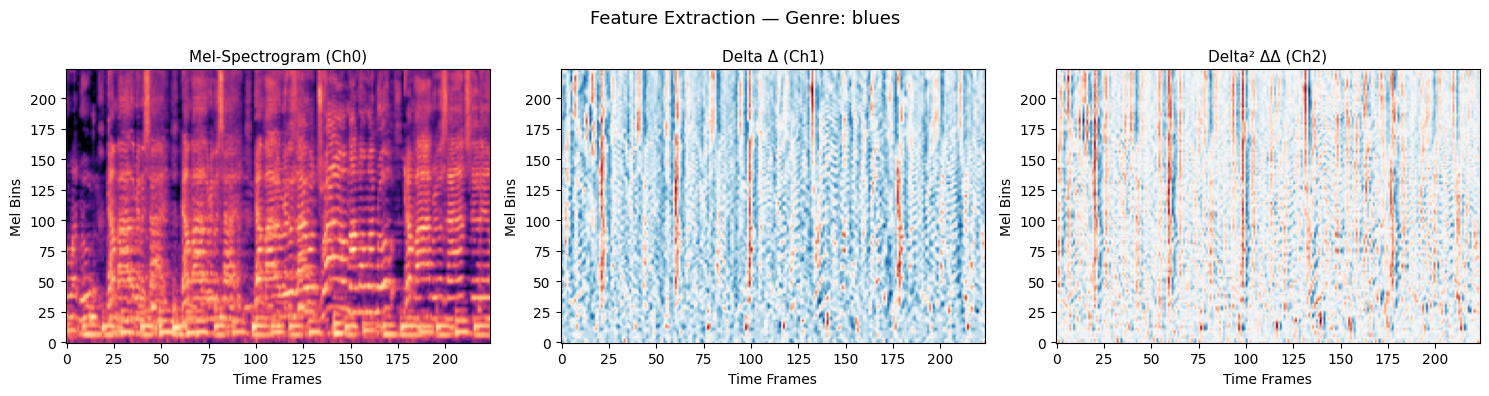


  ✓ All transforms run on CPU inside workers
  ✓ GPU move happens in train_one_epoch() via x.to(device)


In [6]:
_mel_tfm_cpu = T.MelSpectrogram(
    sample_rate=cfg.SAMPLE_RATE, n_fft=cfg.N_FFT,
    hop_length=cfg.HOP_LENGTH, n_mels=cfg.N_MELS, f_max=cfg.FMAX
)   # ← NO .to(cfg.DEVICE) here
_amp2db_cpu = T.AmplitudeToDB(top_db=80)   # ← CPU only


def to_melspec_1ch(wav):
    """
    Waveform [1,T] → normalized mel-spectrogram [1, N_MELS, T'].
    Runs entirely on CPU — safe for DataLoader workers.
    Used by Model 1 (ScratchCNN) and Model 3 (CRNN).
    """
    # wav stays on CPU here — GPU move happens in train loop
    mel = _amp2db_cpu(_mel_tfm_cpu(wav))         # [1, 128, T']
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    return mel                                    # CPU tensor


def to_melspec_3ch(wav, size=224):
    """
    Waveform [1,T] → 3-channel spectrogram [3, size, size].
    Channel 0 : Mel-spectrogram
    Channel 1 : Delta  (Δ)
    Channel 2 : Delta² (ΔΔ)
    Runs entirely on CPU — safe for DataLoader workers.
    Used by Model 2 (EfficientNet).
    """
    mel  = to_melspec_1ch(wav)                           # [1, 128, T']
    d1   = torchaudio.functional.compute_deltas(mel)
    d2   = torchaudio.functional.compute_deltas(d1)
    spec = torch.cat([mel, d1, d2], dim=0)               # [3, 128, T']
    for c in range(3):
        spec[c] = (spec[c] - spec[c].mean()) / (spec[c].std() + 1e-6)
    spec = F.interpolate(spec.unsqueeze(0), (size, size),
                          mode="bilinear", align_corners=False).squeeze(0)
    return spec                                           # CPU tensor


def spec_augment(spec, fmask=30, tmask=50, n=2):
    """SpecAugment: random frequency & time masking. CPU-safe."""
    _, H, W = spec.shape
    for _ in range(n):
        f  = random.randint(0, fmask); f0 = random.randint(0, max(1, H-f))
        spec[:, f0:f0+f, :] = 0.0
        t  = random.randint(0, tmask); t0 = random.randint(0, max(1, W-t))
        spec[:, :, t0:t0+t] = 0.0
    return spec


# ── Verify ───────────────────────────────────────────────────────────
print("=" * 55)
print("  FEATURE EXTRACTION — VERIFIED (CPU-safe)")
print("=" * 55)

if _sample_song:
    _wav = mix_stems_same_song(_sample_song)   # already CPU

    _mel1 = to_melspec_1ch(_wav)
    print(f"\n  to_melspec_1ch()")
    print(f"    Input  shape  : {_wav.shape}   (waveform, CPU)")
    print(f"    Output shape  : {_mel1.shape}  [ch, freq_bins, time_frames]")
    print(f"    Output device : {_mel1.device}  ✓ (safe for workers)")
    print(f"    Freq bins     : {_mel1.shape[1]}")
    print(f"    Time frames   : {_mel1.shape[2]}")
    print(f"    Value range   : [{_mel1.min():.2f}, {_mel1.max():.2f}]")
    print(f"    Mean / Std    : {_mel1.mean():.4f} / {_mel1.std():.4f}")

    _mel3 = to_melspec_3ch(_wav)
    print(f"\n  to_melspec_3ch()")
    print(f"    Input  shape  : {_wav.shape}   (waveform, CPU)")
    print(f"    Output shape  : {_mel3.shape}  [ch, H, W]")
    print(f"    Output device : {_mel3.device}  ✓ (safe for workers)")
    print(f"    Channel 0     : Mel-spectrogram  mean={_mel3[0].mean():.3f}")
    print(f"    Channel 1     : Delta (Δ)        mean={_mel3[1].mean():.3f}")
    print(f"    Channel 2     : Delta² (ΔΔ)      mean={_mel3[2].mean():.3f}")

    _aug = spec_augment(_mel1.clone())
    _masked = (_aug == 0).float().mean().item() * 100
    print(f"\n  spec_augment()")
    print(f"    Pixels zeroed : {_masked:.1f}%  (frequency + time masking)")

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    titles = ["Mel-Spectrogram (Ch0)", "Delta Δ (Ch1)", "Delta² ΔΔ (Ch2)"]
    cmaps  = ["magma", "RdBu_r", "RdBu_r"]
    for i in range(3):
        axes[i].imshow(_mel3[i].numpy(), aspect="auto",
                        origin="lower", cmap=cmaps[i])
        axes[i].set_title(titles[i], fontsize=11)
        axes[i].set_xlabel("Time Frames")
        axes[i].set_ylabel("Mel Bins")
    plt.suptitle(f"Feature Extraction — Genre: {_sample_genre}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{cfg.OUTPUT_DIR}/feature_extraction.png", dpi=130)
    plt.show()

print(f"\n  ✓ All transforms run on CPU inside workers")
print(f"  ✓ GPU move happens in train_one_epoch() via x.to(device)")
print("=" * 55)

# 5. BUILD TRAINING FILE LIST

In [7]:
def build_train_items(stems_dir):
    """
    Scan genres_stems/ and return list of (song_dir, genre, label_int).
    Layout: stems_dir/<genre>/<song_id>/{drums,vocals,bass,others}.wav
    """
    items = []
    for genre in cfg.GENRES:
        gdir = os.path.join(stems_dir, genre)
        if not os.path.isdir(gdir):
            continue
        for song in sorted(os.listdir(gdir)):
            sdir = os.path.join(gdir, song)
            if os.path.isdir(sdir):
                items.append((sdir, genre, cfg.GENRE2IDX[genre]))
    return items


all_items = build_train_items(cfg.STEMS_DIR)
labels    = [it[2] for it in all_items]
tr_items, va_items = train_test_split(
    all_items, test_size=0.15, stratify=labels, random_state=cfg.SEED
)

print("=" * 55)
print("  TRAINING FILE LIST — BUILT")
print("=" * 55)
print(f"\n  Total songs found  : {len(all_items)}")
print(f"  Train split (85%)  : {len(tr_items)}")
print(f"  Val   split (15%)  : {len(va_items)}")

print(f"\n  Per-genre distribution:")
print(f"  {'Genre':<12} {'Total':>7} {'Train':>7} {'Val':>6}")
print(f"  {'─'*35}")
from collections import Counter
tr_counts = Counter(it[1] for it in tr_items)
va_counts = Counter(it[1] for it in va_items)
all_counts= Counter(it[1] for it in all_items)
for g in cfg.GENRES:
    print(f"  {g:<12} {all_counts[g]:>7} {tr_counts[g]:>7} {va_counts[g]:>6}")
print(f"  {'─'*35}")
print(f"  {'TOTAL':<12} {len(all_items):>7} {len(tr_items):>7} {len(va_items):>6}")

print(f"\n  Sample item structure:")
sd, gn, lb = all_items[0]
print(f"    song_dir : {sd}")
print(f"    genre    : {gn}")
print(f"    label    : {lb}")
print(f"\n  Stems available in first song:")
for stem in cfg.STEMS:
    exists = os.path.exists(os.path.join(sd, stem))
    print(f"    {'✓' if exists else '✗'} {stem}")

  TRAINING FILE LIST — BUILT

  Total songs found  : 1000
  Train split (85%)  : 850
  Val   split (15%)  : 150

  Per-genre distribution:
  Genre          Total   Train    Val
  ───────────────────────────────────
  blues            100      85     15
  classical        100      85     15
  country          100      85     15
  disco            100      85     15
  hiphop           100      85     15
  jazz             100      85     15
  metal            100      85     15
  pop              100      85     15
  reggae           100      85     15
  rock             100      85     15
  ───────────────────────────────────
  TOTAL           1000     850    150

  Sample item structure:
    song_dir : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000
    genre    : blues
    label    : 0

  Stems available in first song:
    ✓ drums.wav
    ✓ vocals.wav
    ✓ bass.wav
    ✗ others.wav


# CACHE 

In [8]:
import os, time
import sys
from tqdm import tqdm as tqdm_base

def tqdm(iterable=None, **kwargs):
    kwargs["ascii"] = True
    kwargs["file"]  = sys.stdout
    return tqdm_base(iterable, **kwargs)

CACHE_DIR = "/kaggle/working/mel_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

print("=" * 60)
print("  CELL 6B — PRECOMPUTE MEL SPECTROGRAMS")
print("=" * 60)
print(f"  Cache dir   : {CACHE_DIR}")
print(f"  Total songs : {len(all_items)}")
print(f"  Versions    : 1 clean + 3 mashups = 4 per song")
print(f"  Total files : {len(all_items) * 4 * 2} (1ch + 3ch each)")
print(f"\n  Running once — takes ~10-15 min")
print(f"  After this, training = ~30 sec/epoch instead of 28 min\n")

saved = skipped = 0
start = time.time()

pbar = tqdm(all_items, desc="  Caching", ncols=70)

for song_dir, genre, label in pbar:
    genre_dir = os.path.dirname(song_dir)
    song_name = os.path.basename(song_dir)
    base_key  = f"{genre}_{song_name}"

    # 1-channel clean
    p = os.path.join(CACHE_DIR, f"{base_key}_clean.pt")
    if not os.path.exists(p):
        wav = mix_stems_same_song(song_dir)
        torch.save({"mel": to_melspec_1ch(wav), "label": label}, p)
        saved += 1
    else:
        skipped += 1

    # 3-channel clean
    p3 = os.path.join(CACHE_DIR, f"{base_key}_clean3ch.pt")
    if not os.path.exists(p3):
        wav = mix_stems_same_song(song_dir)
        torch.save({"mel": to_melspec_3ch(wav), "label": label}, p3)
        saved += 1
    else:
        skipped += 1

    # 3 mashup versions
    for i in range(3):
        mp  = os.path.join(CACHE_DIR, f"{base_key}_mashup{i}.pt")
        mp3 = os.path.join(CACHE_DIR, f"{base_key}_mashup3ch{i}.pt")
        if not os.path.exists(mp):
            wav = mashup_different_songs(genre_dir)
            torch.save({"mel": to_melspec_1ch(wav), "label": label}, mp)
            saved += 1
        else:
            skipped += 1
        if not os.path.exists(mp3):
            wav = mashup_different_songs(genre_dir)
            torch.save({"mel": to_melspec_3ch(wav), "label": label}, mp3)
            saved += 1
        else:
            skipped += 1

    pbar.set_postfix(saved=saved, skip=skipped)

pbar.close()
elapsed    = time.time() - start
all_files  = os.listdir(CACHE_DIR)
cache_size = sum(os.path.getsize(os.path.join(CACHE_DIR, f))
                  for f in all_files) / 1e9

print(f"\n  Done!")
print(f"  Saved      : {saved} files")
print(f"  Skipped    : {skipped} (already existed)")
print(f"  Cache size : {cache_size:.2f} GB")
print(f"  Time taken : {time.strftime('%H:%M:%S', time.gmtime(elapsed))}")
print("=" * 60)



  CELL 6B — PRECOMPUTE MEL SPECTROGRAMS
  Cache dir   : /kaggle/working/mel_cache
  Total songs : 1000
  Versions    : 1 clean + 3 mashups = 4 per song
  Total files : 8000 (1ch + 3ch each)

  Running once — takes ~10-15 min
  After this, training = ~30 sec/epoch instead of 28 min

  Caching: 100%|#| 1000/1000 [38:38<00:00,  2.32s/it, saved=8000, skip

  Done!
  Saved      : 8000 files
  Skipped    : 0 (already existed)
  Cache size : 3.31 GB
  Time taken : 00:38:38


# 6. PYTORCH DATASETS

In [9]:
class TrainDataset1Ch(Dataset):
    """
    1-channel mel-spectrogram dataset.
    Used by: Model 1 (ScratchCNN) and Model 3 (CRNN).
    All operations are CPU-only — safe for multiprocessing DataLoader.
    """
    def __init__(self, items, augment=True, mashup_prob=0.6, noise_prob=0.7):
        self.items = items; self.augment = augment
        self.mashup_prob = mashup_prob; self.noise_prob = noise_prob

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        song_dir, genre, label = self.items[idx]
        genre_dir = os.path.dirname(song_dir)

        # Step 1: Load waveform (CPU)
        if self.augment and random.random() < self.mashup_prob:
            wav = mashup_different_songs(genre_dir)
        else:
            wav = mix_stems_same_song(song_dir)
        # wav is CPU tensor here ✓

        # Step 2: Noise augmentation (CPU)
        if self.augment and random.random() < self.noise_prob:
            if random.random() < 0.6:
                wav = add_esc50_noise(wav, (5, 25))
            else:
                wav = add_gaussian_noise(wav, (10, 30))

        # Step 3: Time-stretch (CPU)
        if self.augment and random.random() < 0.3:
            rate  = random.uniform(0.85, 1.15)
            new_sr = int(cfg.SAMPLE_RATE * rate)
            wav = torchaudio.functional.resample(wav, cfg.SAMPLE_RATE, new_sr)
            tgt = cfg.SAMPLE_RATE * cfg.DURATION
            wav = (wav[:, :tgt] if wav.shape[1] >= tgt
                   else F.pad(wav, (0, tgt - wav.shape[1])))

        # Step 4: Mel-spec (CPU) — GPU move done in training loop
        mel = to_melspec_1ch(wav)          # returns CPU tensor ✓
        return mel, torch.tensor(label, dtype=torch.long)


class TrainDataset3Ch(Dataset):
    """
    3-channel mel-spectrogram dataset.
    Used by: Model 2 (EfficientNet-B2).
    All operations are CPU-only — safe for multiprocessing DataLoader.
    """
    def __init__(self, items, augment=True, mashup_prob=0.6, noise_prob=0.7):
        self.items = items; self.augment = augment
        self.mashup_prob = mashup_prob; self.noise_prob = noise_prob

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        song_dir, genre, label = self.items[idx]
        genre_dir = os.path.dirname(song_dir)

        if self.augment and random.random() < self.mashup_prob:
            wav = mashup_different_songs(genre_dir)
        else:
            wav = mix_stems_same_song(song_dir)

        if self.augment and random.random() < self.noise_prob:
            if random.random() < 0.6:
                wav = add_esc50_noise(wav, (5, 25))
            else:
                wav = add_gaussian_noise(wav, (10, 30))

        spec = to_melspec_3ch(wav)           # CPU tensor ✓
        if self.augment and random.random() < 0.5:
            spec = spec_augment(spec)
        return spec, torch.tensor(label, dtype=torch.long)


class TestDataset(Dataset):
    """
    Loads flat mashup .wav files from mashups/ directory.
    All CPU — safe for multiprocessing DataLoader.
    """
    def __init__(self, test_df, mashup_dir, three_channel=False):
        self.records    = test_df.to_dict("records")
        self.mashup_dir = mashup_dir
        self.three_ch   = three_channel
        self.fname_col  = next(
            (c for c in ["filename","file","path","audio","name"]
             if c in test_df.columns), None
        )

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        row = self.records[idx]
        sid = str(row["id"]).zfill(4)
        if self.fname_col:
            path = os.path.join(self.mashup_dir, row[self.fname_col])
        else:
            path = None
            for name in [f"{sid}.wav", f"{row['id']}.wav",
                          f"mashup_{sid}.wav", f"{sid}.mp3"]:
                cand = os.path.join(self.mashup_dir, name)
                if os.path.exists(cand):
                    path = cand; break
            if path is None:
                path = os.path.join(self.mashup_dir, f"{sid}.wav")
        wav  = load_wav(path, random_crop=False)    # CPU ✓
        spec = to_melspec_3ch(wav) if self.three_ch else to_melspec_1ch(wav)
        return spec, sid                            # CPU ✓


# ── Verify datasets ───────────────────────────────────────────────────
print("=" * 55)
print("  PYTORCH DATASETS — VERIFIED (CPU-safe)")
print("=" * 55)

_ds1 = TrainDataset1Ch(tr_items[:4], augment=True)
_ds3 = TrainDataset3Ch(tr_items[:4], augment=True)
_x1, _y1 = _ds1[0]
_x3, _y3 = _ds3[0]

print(f"\n  TrainDataset1Ch:")
print(f"    Train size     : {len(TrainDataset1Ch(tr_items))}")
print(f"    Val size       : {len(TrainDataset1Ch(va_items))}")
print(f"    Sample shape   : {_x1.shape}   ✓ CPU: {_x1.device}")
print(f"    Sample label   : {_y1.item()} ({cfg.IDX2GENRE[_y1.item()]})")

print(f"\n  TrainDataset3Ch:")
print(f"    Train size     : {len(TrainDataset3Ch(tr_items))}")
print(f"    Val size       : {len(TrainDataset3Ch(va_items))}")
print(f"    Sample shape   : {_x3.shape}  ✓ CPU: {_x3.device}")
print(f"    Sample label   : {_y3.item()} ({cfg.IDX2GENRE[_y3.item()]})")

# Quick DataLoader smoke test with num_workers=2
_smoke_dl = DataLoader(_ds1, batch_size=2, num_workers=2)
_bx, _by  = next(iter(_smoke_dl))
print(f"\n  DataLoader smoke test (num_workers=2):")
print(f"    Batch shape    : {_bx.shape}  ✓ no CUDA fork error")
print(f"    Labels         : {_by.tolist()}")

print(f"\n  Key fix summary:")
print(f"    ✗ BEFORE: to_melspec called .to(cfg.DEVICE) inside worker")
print(f"    ✓ AFTER : transforms stay on CPU in workers")
print(f"    ✓ GPU move happens in train_one_epoch: x.to(device)")
print("=" * 55)


  PYTORCH DATASETS — VERIFIED (CPU-safe)

  TrainDataset1Ch:
    Train size     : 850
    Val size       : 150
    Sample shape   : torch.Size([1, 128, 431])   ✓ CPU: cpu
    Sample label   : 3 (disco)

  TrainDataset3Ch:
    Train size     : 850
    Val size       : 150
    Sample shape   : torch.Size([3, 224, 224])  ✓ CPU: cpu
    Sample label   : 3 (disco)

  DataLoader smoke test (num_workers=2):
    Batch shape    : torch.Size([2, 1, 128, 431])  ✓ no CUDA fork error
    Labels         : [3, 6]

  Key fix summary:
    ✗ BEFORE: to_melspec called .to(cfg.DEVICE) inside worker
    ✓ AFTER : transforms stay on CPU in workers
    ✓ GPU move happens in train_one_epoch: x.to(device)


# CachedDataset1Ch

In [10]:
class CachedDataset1Ch(Dataset):
    """
    Loads precomputed 1ch mel specs from disk.
    Way faster than computing from raw wav every batch.
    Used by: Model 1 (ScratchCNN) and Model 3 (CRNN)
    """
    def __init__(self, items, augment=True, noise_prob=0.5):
        self.augment    = augment
        self.noise_prob = noise_prob
        self.cache_keys = []

        for song_dir, genre, label in items:
            song_name = os.path.basename(song_dir)
            base_key  = f"{genre}_{song_name}"

            # clean version
            p = os.path.join(CACHE_DIR, f"{base_key}_clean.pt")
            if os.path.exists(p):
                self.cache_keys.append(p)

            # mashup versions
            for i in range(3):
                mp = os.path.join(CACHE_DIR, f"{base_key}_mashup{i}.pt")
                if os.path.exists(mp):
                    self.cache_keys.append(mp)

    def __len__(self):
        return len(self.cache_keys)

    def __getitem__(self, idx):
        data  = torch.load(self.cache_keys[idx], weights_only=True)
        mel   = data["mel"]
        label = data["label"]

        # Cheap noise on mel (no wav load needed)
        if self.augment and random.random() < self.noise_prob:
            std = random.uniform(0.01, 0.08)
            mel = mel + std * torch.randn_like(mel)
            mel = (mel - mel.mean()) / (mel.std() + 1e-6)

        # SpecAugment
        if self.augment and random.random() < 0.4:
            mel = spec_augment(mel, fmask=20, tmask=30, n=1)

        return mel, torch.tensor(label, dtype=torch.long)


class CachedDataset3Ch(Dataset):
    """
    Loads precomputed 3ch mel specs from disk.
    Used by: Model 2 (EfficientNet-B2)
    """
    def __init__(self, items, augment=True, noise_prob=0.5):
        self.augment    = augment
        self.noise_prob = noise_prob
        self.cache_keys = []

        for song_dir, genre, label in items:
            song_name = os.path.basename(song_dir)
            base_key  = f"{genre}_{song_name}"

            p = os.path.join(CACHE_DIR, f"{base_key}_clean3ch.pt")
            if os.path.exists(p):
                self.cache_keys.append(p)

            for i in range(3):
                mp = os.path.join(CACHE_DIR, f"{base_key}_mashup3ch{i}.pt")
                if os.path.exists(mp):
                    self.cache_keys.append(mp)

    def __len__(self):
        return len(self.cache_keys)

    def __getitem__(self, idx):
        data  = torch.load(self.cache_keys[idx], weights_only=True)
        spec  = data["mel"]
        label = data["label"]

        if self.augment and random.random() < self.noise_prob:
            std  = random.uniform(0.01, 0.05)
            spec = spec + std * torch.randn_like(spec)
            for c in range(3):
                spec[c] = (spec[c]-spec[c].mean())/(spec[c].std()+1e-6)

        if self.augment and random.random() < 0.5:
            spec = spec_augment(spec, fmask=25, tmask=40, n=2)

        return spec, torch.tensor(label, dtype=torch.long)


# ── Speed test ────────────────────────────────────────────────────────
print("=" * 60)
print("  CELL 7B — CACHED DATASETS READY")
print("=" * 60)

_c1 = CachedDataset1Ch(tr_items, augment=True)
_c3 = CachedDataset3Ch(tr_items, augment=True)

print(f"\n  CachedDataset1Ch  samples : {len(_c1)}")
print(f"  CachedDataset3Ch  samples : {len(_c3)}")

# Speed test
start = time.time()
for i in range(20):
    _ = _c1[i]
t1 = (time.time()-start)/20*1000

start = time.time()
for i in range(20):
    _ = _c3[i]
t3 = (time.time()-start)/20*1000

print(f"\n  Speed per sample:")
print(f"    Old (raw wav)  : ~3000 ms")
print(f"    New 1ch cached : {t1:.1f} ms  ✓")
print(f"    New 3ch cached : {t3:.1f} ms  ✓")
print(f"\n  Estimated epoch time:")
print(f"    Old : ~28 min/epoch")
print(f"    New : ~{t1*cfg.BATCH_SIZE/1000*len(_c1)//cfg.BATCH_SIZE:.0f} sec/epoch  ✓")
print("=" * 60)
print("  Cell 7B complete — now run Cell 8")


  CELL 7B — CACHED DATASETS READY

  CachedDataset1Ch  samples : 3400
  CachedDataset3Ch  samples : 3400

  Speed per sample:
    Old (raw wav)  : ~3000 ms
    New 1ch cached : 2.6 ms  ✓
    New 3ch cached : 1.4 ms  ✓

  Estimated epoch time:
    Old : ~28 min/epoch
    New : ~8 sec/epoch  ✓
  Cell 7B complete — now run Cell 8


# 7. LOSS FUNCTION & TRAINING UTILITIES

In [11]:
import os, sys, time, random
os.environ["TQDM_NOTEBOOK"] = "0"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

# ── Suppress inner-loop bars entirely ──────────────────────────────────────────
class _SilentBar:
    """Drop-in tqdm replacement that does nothing."""
    def __init__(self, iterable=None, **kw): self._it = iterable
    def __iter__(self):              return iter(self._it)
    def set_postfix(self, **kw):    pass
    def close(self):                pass
    def __enter__(self):            return self
    def __exit__(self, *a):         pass

def _hms(s):
    s = max(0, int(s))
    return f"{s//3600:02d}:{(s%3600)//60:02d}:{s%60:02d}"


# ── Label Smoothing Loss ────────────────────────────────────────────────────────
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=cfg.NUM_CLASSES, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.cls = classes

    def forward(self, pred, target):
        conf = 1.0 - self.smoothing
        sv   = self.smoothing / (self.cls - 1)
        oh   = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        sm   = oh * conf + (1 - oh) * sv
        return -(sm * F.log_softmax(pred, -1)).sum(-1).mean()


# ── Mixup ───────────────────────────────────────────────────────────────────────
def mixup(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


# ── Train one epoch (silent inner loop) ────────────────────────────────────────
def train_one_epoch(model, loader, opt, crit, device, use_mixup=True):
    model.train()
    tot_loss = corr = tot = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        if use_mixup and random.random() < 0.5:
            xm, ya, yb, lam = mixup(x, y)
            logits = model(xm)
            loss   = lam * crit(logits, ya) + (1 - lam) * crit(logits, yb)
        else:
            logits = model(x)
            loss   = crit(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tot_loss += loss.item() * x.size(0)
        corr     += (logits.argmax(1) == y).sum().item()
        tot      += x.size(0)
    return tot_loss / tot, corr / tot


# ── Validate (silent inner loop) ────────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader, crit, device):
    model.eval()
    preds, labs = [], []
    tot_loss = tot = 0
    for x, y in loader:
        x, y   = x.to(device), y.to(device)
        logits  = model(x)
        tot_loss += crit(logits, y).item() * x.size(0)
        preds.extend(logits.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
        tot += x.size(0)
    return tot_loss / tot, f1_score(labs, preds, average="macro")


# ── TTA Predict (one compact line per pass) ─────────────────────────────────────
@torch.no_grad()
def predict_tta(model, loader, device, tta=5, noise_std=0.015):
    model.eval()
    all_probs, all_ids = [], []
    for t in range(tta):
        p_t, id_t = [], []
        for x, ids in loader:
            x = x.to(device)
            if t > 0:
                x = x + noise_std * torch.randn_like(x)
            probs = F.softmax(model(x), -1).cpu().numpy()
            p_t.extend(probs); id_t.extend(ids)
        all_probs.append(np.array(p_t))
        if t == 0: all_ids = id_t
        print(f"  TTA {t+1}/{tta} done", end="\r")
    print()
    return all_ids, np.mean(all_probs, axis=0)


# ── Main training loop — ONE LINE per epoch ─────────────────────────────────────
def train_model(model, tr_dl, va_dl, name, lr, epochs, patience=10):
    crit  = LabelSmoothingLoss()
    opt   = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=cfg.WEIGHT_DECAY
    )
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=10, T_mult=2, eta_min=1e-6
    )

    best_f1 = no_imp = 0
    save    = f"{cfg.OUTPUT_DIR}/{name}.pth"
    history = {"train_loss": [], "train_acc": [], "val_f1": []}
    ep_times = []

    n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    col  = 62
    print(f"\n  ┌{'─'*col}┐")
    print(f"  │  {name:<{col-2}}│")
    print(f"  │  Params: {n_tr:,}  |  LR: {lr}  |  Epochs: {epochs}  |  Patience: {patience}{'':>{col - 50}}│")
    print(f"  ├{'─'*col}┤")
    print(f"  │  {'Ep':>5}  {'Loss':>7}  {'Acc':>6}  {'F1':>7}  {'Best':>7}  {'Time':>8}  {'ETA':>8}  {'':>3}│")
    print(f"  ├{'─'*col}┤")

    for ep in range(1, epochs + 1):
        t0          = time.time()
        tl, ta      = train_one_epoch(model, tr_dl, opt, crit, cfg.DEVICE)
        vl, vf      = validate(model, va_dl, crit, cfg.DEVICE)
        sched.step(ep)
        ep_time     = time.time() - t0
        ep_times.append(ep_time)
        eta         = (sum(ep_times) / len(ep_times)) * (epochs - ep)

        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_f1"].append(vf)

        flag = "✓" if vf > best_f1 else " "
        if vf > best_f1:
            best_f1 = vf; no_imp = 0
            torch.save(model.state_dict(), save)
        else:
            no_imp += 1

        print(f"  │  {ep:>3}/{epochs}  {tl:>7.4f}  {ta:>6.3f}  "
              f"{vf:>7.4f}  {best_f1:>7.4f}  {_hms(ep_time):>8}  {_hms(eta):>8}  {flag:>3}│")

        if no_imp >= patience:
            print(f"  │  Early stop at epoch {ep:<{col-25}}│")
            break

    print(f"  └{'─'*col}┘")
    print(f"  ✔  {name}  |  Best F1: {best_f1:.4f}  |  Total: {_hms(sum(ep_times))}\n")

    model.load_state_dict(torch.load(save, map_location=cfg.DEVICE))
    return model, best_f1, history


# ── Smoke test ──────────────────────────────────────────────────────────────────
print("=" * 50)
print("  Cell 8 ready — LabelSmoothingLoss · mixup · train_model")
_lv = LabelSmoothingLoss()(torch.randn(4, 10), torch.randint(0, 10, (4,)))
print(f"  Loss test : {_lv.item():.4f}  ✓   hms: {_hms(3725)}  ✓")
print("=" * 50)

  Cell 8 ready — LabelSmoothingLoss · mixup · train_model
  Loss test : 3.2582  ✓   hms: 01:02:05  ✓


# 8. MODELS

# i) CUSTOM MULTI-SCALE CNN (FROM SCRATCH)

In [12]:
class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        b = out_ch // 4
        self.b1 = nn.Sequential(nn.Conv2d(in_ch,b,1),           nn.BatchNorm2d(b), nn.ReLU())
        self.b3 = nn.Sequential(nn.Conv2d(in_ch,b,3,padding=1), nn.BatchNorm2d(b), nn.ReLU())
        self.b5 = nn.Sequential(nn.Conv2d(in_ch,b,5,padding=2), nn.BatchNorm2d(b), nn.ReLU())
        self.bp = nn.Sequential(nn.MaxPool2d(3,1,1),
                                nn.Conv2d(in_ch,b,1), nn.BatchNorm2d(b), nn.ReLU())

    def forward(self, x):
        return torch.cat([self.b1(x), self.b3(x), self.b5(x), self.bp(x)], 1)


class ResBlock(nn.Module):
    def __init__(self, ic, oc, pool=2, drop=0.2):
        super().__init__()
        self.c1   = nn.Conv2d(ic,oc,3,padding=1); self.b1 = nn.BatchNorm2d(oc)
        self.c2   = nn.Conv2d(oc,oc,3,padding=1); self.b2 = nn.BatchNorm2d(oc)
        self.pool = nn.AvgPool2d(pool)
        self.drop = nn.Dropout2d(drop)
        self.skip = nn.Conv2d(ic,oc,1) if ic != oc else nn.Identity()

    def forward(self, x):
        s = self.skip(x)
        x = F.relu(self.b1(self.c1(x)))
        x = F.relu(self.b2(self.c2(x)))
        x = x + F.adaptive_avg_pool2d(s, x.shape[2:])
        return self.pool(self.drop(x))


class MultiScaleCNN(nn.Module):          # ← renamed from ScratchCNN
    def __init__(self, nc=cfg.NUM_CLASSES, drop=0.4):
        super().__init__()
        self.ms = MultiScaleBlock(1, 32)
        self.p0 = nn.AvgPool2d(2)
        self.l1 = ResBlock(32,  64,  drop=0.20)
        self.l2 = ResBlock(64,  128, drop=0.25)
        self.l3 = ResBlock(128, 256, drop=0.30)
        self.l4 = ResBlock(256, 512, drop=0.30)
        self.ta = nn.Sequential(
            nn.Conv1d(512,128,1), nn.Tanh(),
            nn.Conv1d(128,512,1), nn.Softmax(dim=-1)
        )
        self.head = nn.Sequential(
            nn.Linear(1024,512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(drop*0.5),
            nn.Linear(256, nc)
        )

    def forward(self, x):
        x = self.p0(self.ms(x))
        x = self.l1(x); x = self.l2(x)
        x = self.l3(x); x = self.l4(x)
        x = x.mean(2)
        a = self.ta(x)
        x = torch.cat([(x*a).sum(-1), x.max(-1).values], 1)
        return self.head(x)


# ── Smoke test ────────────────────────────────────────────
_m      = MultiScaleCNN().to(cfg.DEVICE)
_dummy  = torch.randn(2, 1, 128, 431).to(cfg.DEVICE)
_out    = _m(_dummy)
_total  = sum(p.numel() for p in _m.parameters())
col = 44
print(f"\n  ┌{'─'*col}┐")
print(f"  │  {'MODEL 1 — MultiScaleCNN (Scratch)':<{col-2}}│")
print(f"  ├{'─'*col}┤")
print(f"  │  Input  : {str(_dummy.shape):<{col-10}}│")
print(f"  │  Output : {str(_out.shape):<{col-10}}│")
print(f"  │  Params : {_total:,}{'':<{col-18}}│")
print(f"  └{'─'*col}┘")
del _m, _dummy, _out


  ┌────────────────────────────────────────────┐
  │  MODEL 1 — MultiScaleCNN (Scratch)         │
  ├────────────────────────────────────────────┤
  │  Input  : torch.Size([2, 1, 128, 431])      │
  │  Output : torch.Size([2, 10])               │
  │  Params : 5,672,778                          │
  └────────────────────────────────────────────┘


# ii) PRETRAINED EFFICIENTNET-B2

In [13]:
class EfficientNetAudio(nn.Module):
    def __init__(self, nc=cfg.NUM_CLASSES, drop=0.4, freeze=True):
        super().__init__()
        self.net = models.efficientnet_b2(
            weights="EfficientNet_B2_Weights.DEFAULT"  # ← fixed
        )
        in_feat = self.net.classifier[1].in_features
        self.net.classifier = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(in_feat, 512), nn.ReLU(),
            nn.Dropout(drop * 0.5),
            nn.Linear(512, nc)
        )
        if freeze:
            for p in self.net.features.parameters():
                p.requires_grad = False
            for p in self.net.features[-2:].parameters():
                p.requires_grad = True

    def unfreeze(self):
        for p in self.net.parameters():
            p.requires_grad = True

    def forward(self, x):
        return self.net(x)


# ── Smoke test ────────────────────────────────────────────
_m2     = EfficientNetAudio(freeze=True).to(cfg.DEVICE)
_dummy3 = torch.randn(2, 3, 224, 224).to(cfg.DEVICE)
_out2   = _m2(_dummy3)
_total2 = sum(p.numel() for p in _m2.parameters())
_train2 = sum(p.numel() for p in _m2.parameters() if p.requires_grad)
_m2.unfreeze()
_train2_full = sum(p.numel() for p in _m2.parameters() if p.requires_grad)

col = 44
print(f"\n  ┌{'─'*col}┐")
print(f"  │  {'MODEL 2 — EfficientNet-B2 (Pretrained)':<{col-2}}│")
print(f"  ├{'─'*col}┤")
print(f"  │  Input  : {str(_dummy3.shape):<{col-10}}│")
print(f"  │  Output : {str(_out2.shape):<{col-10}}│")
print(f"  ├{'─'*col}┤")
print(f"  │  Phase 1 — Trainable : {_train2:,}{'':<{col-28}}│")
print(f"  │  Phase 1 — Frozen    : {_total2-_train2:,}{'':<{col-28}}│")
print(f"  │  Phase 2 — Trainable : {_train2_full:,}{'':<{col-28}}│")
print(f"  └{'─'*col}┘")

del _m2, _dummy3, _out2

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 178MB/s]



  ┌────────────────────────────────────────────┐
  │  MODEL 2 — EfficientNet-B2 (Pretrained)    │
  ├────────────────────────────────────────────┤
  │  Input  : torch.Size([2, 3, 224, 224])      │
  │  Output : torch.Size([2, 10])               │
  ├────────────────────────────────────────────┤
  │  Phase 1 — Trainable : 3,960,790                │
  │  Phase 1 — Frozen    : 4,466,742                │
  │  Phase 2 — Trainable : 8,427,532                │
  └────────────────────────────────────────────┘


# iii) CRNN (CNN + BiGRU + ATTENTION)

In [14]:
class FrameEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,1,1),   nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32,32,3,1,1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d((2,1)), nn.Dropout2d(0.1),
            nn.Conv2d(32,64,3,1,1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,64,3,1,1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,1)), nn.Dropout2d(0.1),
            nn.Conv2d(64,128,3,1,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128,3,1,1),nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,1)), nn.Dropout2d(0.15),
            nn.Conv2d(128,256,3,1,1),nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2,1)),
        )
        self.out_dim = 256 * 8

    def forward(self, x):
        x = self.net(x)
        B, C, F, Tt = x.shape
        return x.permute(0, 3, 1, 2).reshape(B, Tt, C * F)


class CRNN(nn.Module):
    def __init__(self, nc=cfg.NUM_CLASSES, hidden=256, gru_layers=2, drop=0.4):
        super().__init__()
        self.enc  = FrameEncoder()
        self.proj = nn.Sequential(
            nn.Linear(self.enc.out_dim, hidden*2), nn.LayerNorm(hidden*2), nn.ReLU(),
            nn.Dropout(drop * 0.5),
            nn.Linear(hidden*2, hidden), nn.LayerNorm(hidden), nn.ReLU()
        )
        self.gru  = nn.GRU(hidden, hidden, gru_layers,
                           batch_first=True, bidirectional=True,
                           dropout=drop if gru_layers > 1 else 0.)
        rnn_d = hidden * 2
        self.mha  = nn.MultiheadAttention(rnn_d, 8, dropout=0.1, batch_first=True)
        self.norm = nn.LayerNorm(rnn_d)
        self.pw   = nn.Linear(rnn_d, 1)
        self.head = nn.Sequential(
            nn.Linear(rnn_d*2, 512), nn.LayerNorm(512), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(512, 256),     nn.ReLU(), nn.Dropout(drop * 0.5),
            nn.Linear(256, nc)
        )

    def forward(self, x):
        x = self.proj(self.enc(x))
        x, _ = self.gru(x)
        att, _ = self.mha(x, x, x)
        x = self.norm(x + att)
        w = F.softmax(self.pw(x).squeeze(-1), -1).unsqueeze(-1)
        return self.head(torch.cat([(x * w).sum(1), x.mean(1)], 1))


# ── Smoke test ────────────────────────────────────────────
_dummy  = torch.randn(2, 1, 128, 431).to(cfg.DEVICE)
_m3     = CRNN().to(cfg.DEVICE)
_out3   = _m3(_dummy)
_total3 = sum(p.numel() for p in _m3.parameters())
_enc3   = FrameEncoder().to(cfg.DEVICE)
_enc_out= _enc3(_dummy)

col = 44
print(f"\n  ┌{'─'*col}┐")
print(f"  │  {'MODEL 3 — CRNN (CNN + BiGRU + Attention)':<{col-2}}│")
print(f"  ├{'─'*col}┤")
print(f"  │  Input         : {str(_dummy.shape):<{col-18}}│")
print(f"  │  FrameEncoder  : {str(_enc_out.shape):<{col-18}}│")
print(f"  │  Output        : {str(_out3.shape):<{col-18}}│")
print(f"  ├{'─'*col}┤")
print(f"  │  Params        : {_total3:,}{'':<{col-22}}│")
print(f"  └{'─'*col}┘")

del _m3, _enc3, _dummy, _out3, _enc_out


  ┌────────────────────────────────────────────┐
  │  MODEL 3 — CRNN (CNN + BiGRU + Attention)  │
  ├────────────────────────────────────────────┤
  │  Input         : torch.Size([2, 1, 128, 431])│
  │  FrameEncoder  : torch.Size([2, 431, 2048])│
  │  Output        : torch.Size([2, 10])       │
  ├────────────────────────────────────────────┤
  │  Params        : 5,449,067                      │
  └────────────────────────────────────────────┘


# 9. MODEL COMPARISON SUMMARY

In [15]:
print("  MODEL COMPARISON SUMMARY")
print("=" * 65)
print(f"\n  {'Property':<28} {'Model1':>10} {'Model2':>12} {'Model3':>10}")
print(f"  {'─'*62}")

rows = [
    ("Architecture",        "ScratchCNN",  "EfficientNet", "CRNN"),
    ("Type",                "From Scratch","Pretrained",    "From Scratch"),
    ("Input channels",      "1",           "3",             "1"),
    ("Input size",          "1×128×T",     "3×224×224",     "1×128×T"),
    ("Pretrained weights",  "None",        "ImageNet",      "None"),
    ("Temporal model",      "Att Pool",    "GlobalAvgPool", "BiGRU+MHA"),
    ("Parameters",          f"{_total:,}",  f"{_total2:,}", f"{_total3:,}"),
    ("SpecAugment",         "No",          "Yes",           "No"),
    ("MixUp training",      "Yes",         "Yes",           "Yes"),
]
for name, v1, v2, v3 in rows:
    print(f"  {name:<28} {v1:>10} {v2:>12} {v3:>10}")

print(f"  {'─'*62}")
print(f"\n  Ensemble strategy:")
print(f"    → Soft-voting (average softmax probabilities)")
print(f"    → Weights optimized on validation set (Dirichlet search)")
print(f"    → Test-Time Augmentation: 5 passes with noise perturbation")
print("=" * 65)


  MODEL COMPARISON SUMMARY

  Property                         Model1       Model2     Model3
  ──────────────────────────────────────────────────────────────
  Architecture                 ScratchCNN EfficientNet       CRNN
  Type                         From Scratch   Pretrained From Scratch
  Input channels                        1            3          1
  Input size                      1×128×T    3×224×224    1×128×T
  Pretrained weights                 None     ImageNet       None
  Temporal model                 Att Pool GlobalAvgPool  BiGRU+MHA
  Parameters                    5,672,778    8,427,532  5,449,067
  SpecAugment                          No          Yes         No
  MixUp training                      Yes          Yes        Yes
  ──────────────────────────────────────────────────────────────

  Ensemble strategy:
    → Soft-voting (average softmax probabilities)
    → Weights optimized on validation set (Dirichlet search)
    → Test-Time Augmentation: 5 passes with 

# 10. TRAINING 

# i) TRAINING SCRATCH CNN

  Training Model 1 — MultiScaleCNN …

  ┌──────────────────────────────────────────────────────────────┐
  │  model1_scratch                                              │
  │  Params: 5,672,778  |  LR: 0.001  |  Epochs: 50  |  Patience: 10            │
  ├──────────────────────────────────────────────────────────────┤
  │     Ep     Loss     Acc       F1     Best      Time       ETA     │
  ├──────────────────────────────────────────────────────────────┤
  │    1/50   2.0260   0.259   0.2594   0.2594  00:00:21  00:17:52    ✓│
  │    2/50   1.8269   0.356   0.3966   0.3966  00:00:21  00:17:22    ✓│
  │    3/50   1.7875   0.376   0.4556   0.4556  00:00:21  00:17:05    ✓│
  │    4/50   1.6875   0.412   0.4065   0.4556  00:00:22  00:16:49     │
  │    5/50   1.6333   0.422   0.4947   0.4947  00:00:22  00:16:35    ✓│
  │    6/50   1.5914   0.439   0.5516   0.5516  00:00:23  00:16:22    ✓│
  │    7/50   1.5572   0.420   0.6257   0.6257  00:00:24  00:16:11    ✓│
  │    8/50   1.5294   0.470 

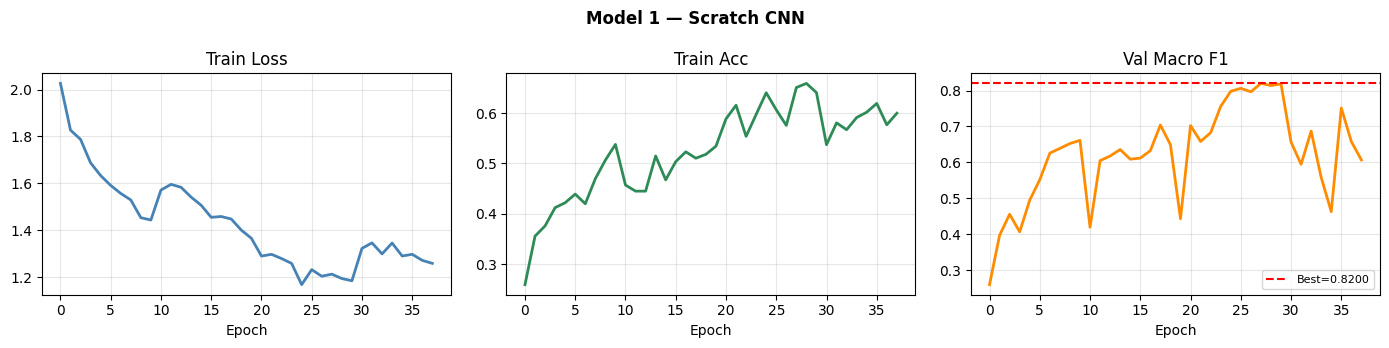

  Model 1  Best Val F1 : 0.8200


In [16]:
print("  Training Model 1 — MultiScaleCNN …")

tr_dl1 = DataLoader(CachedDataset1Ch(tr_items, augment=True),   # ← 1Ch not 3Ch
                    batch_size=32, shuffle=True,
                    num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
va_dl1 = DataLoader(CachedDataset1Ch(va_items, augment=False),  # ← 1Ch not 3Ch
                    batch_size=32, shuffle=False,
                    num_workers=cfg.NUM_WORKERS, pin_memory=True)

m1, f1_m1, hist1 = train_model(
    MultiScaleCNN().to(cfg.DEVICE),
    tr_dl1, va_dl1, "model1_scratch",
    lr=1e-3, epochs=cfg.EPOCHS, patience=10
)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, data, title, col in zip(
    axes,
    [hist1["train_loss"], hist1["train_acc"], hist1["val_f1"]],
    ["Train Loss", "Train Acc", "Val Macro F1"],
    ["steelblue", "seagreen", "darkorange"]
):
    ax.plot(data, color=col, lw=2); ax.set_title(title)
    ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
axes[2].axhline(f1_m1, ls="--", color="red", lw=1.5, label=f"Best={f1_m1:.4f}")
axes[2].legend(fontsize=8)
plt.suptitle("Model 1 — Scratch CNN", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/model1_history.png", dpi=130)
plt.show()
print(f"  Model 1  Best Val F1 : {f1_m1:.4f}")


# ii) TRAINING PRETRAINED EFFICIENTNET

  Training Model 2 — EfficientNet-B2 …
  Phase 1/2 — Warmup (frozen backbone, 5 ep)

  ┌──────────────────────────────────────────────────────────────┐
  │  model2_effnet_warm                                          │
  │  Params: 3,960,790  |  LR: 0.001  |  Epochs: 5  |  Patience: 5            │
  ├──────────────────────────────────────────────────────────────┤
  │     Ep     Loss     Acc       F1     Best      Time       ETA     │
  ├──────────────────────────────────────────────────────────────┤
  │    1/5   1.8003   0.371   0.6480   0.6480  00:00:11  00:00:45    ✓│
  │    2/5   1.4693   0.526   0.6739   0.6739  00:00:11  00:00:33    ✓│
  │    3/5   1.3261   0.555   0.7409   0.7409  00:00:11  00:00:22    ✓│
  │    4/5   1.3129   0.584   0.7496   0.7496  00:00:11  00:00:11    ✓│
  │    5/5   1.2072   0.629   0.7428   0.7496  00:00:11  00:00:00     │
  └──────────────────────────────────────────────────────────────┘
  ✔  model2_effnet_warm  |  Best F1: 0.7496  |  Total: 00:00:56

  P

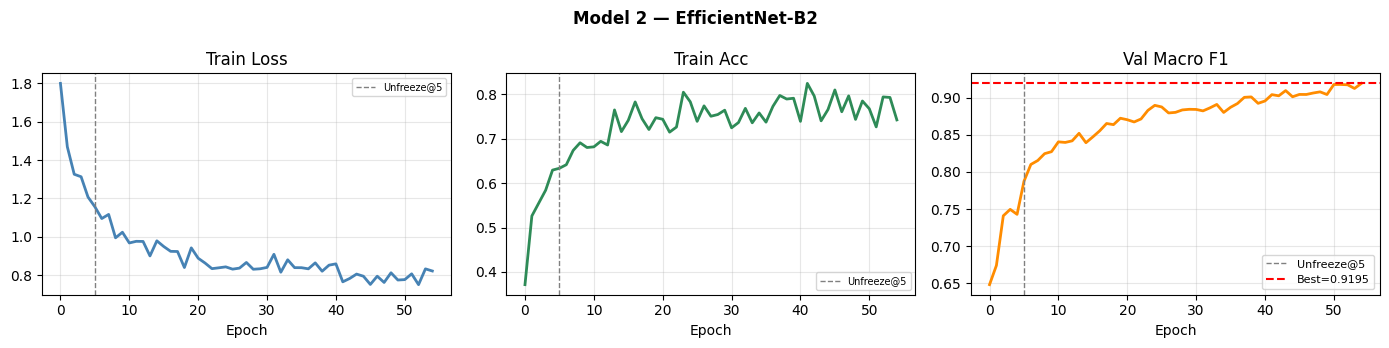

  Model 2  Best Val F1 : 0.9195


In [17]:
print("  Training Model 2 — EfficientNet-B2 …")
tr_dl2 = DataLoader(CachedDataset3Ch(tr_items, augment=True),
                    batch_size=24, shuffle=True,
                    num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
va_dl2 = DataLoader(CachedDataset3Ch(va_items, augment=False),
                    batch_size=24, shuffle=False,
                    num_workers=cfg.NUM_WORKERS, pin_memory=True)

# Phase 1 — warmup
print("  Phase 1/2 — Warmup (frozen backbone, 5 ep)")
m2 = EfficientNetAudio(freeze=True).to(cfg.DEVICE)
m2, _, hist2a = train_model(m2, tr_dl2, va_dl2,
                             "model2_effnet_warm",
                             lr=1e-3, epochs=5, patience=5)

# Phase 2 — fine-tune
print("  Phase 2/2 — Fine-tune (all layers)")
m2.unfreeze()
m2, f1_m2, hist2b = train_model(m2, tr_dl2, va_dl2,
                                 "model2_effnet",
                                 lr=5e-5, epochs=cfg.EPOCHS, patience=10)

hist2_loss   = hist2a["train_loss"] + hist2b["train_loss"]
hist2_acc    = hist2a["train_acc"]  + hist2b["train_acc"]
hist2_f1     = hist2a["val_f1"]     + hist2b["val_f1"]
unfreeze_ep  = len(hist2a["val_f1"])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, data, title, col in zip(
    axes,
    [hist2_loss, hist2_acc, hist2_f1],
    ["Train Loss", "Train Acc", "Val Macro F1"],
    ["steelblue", "seagreen", "darkorange"]
):
    ax.plot(data, color=col, lw=2); ax.set_title(title)
    ax.axvline(unfreeze_ep, color="gray", ls="--", lw=1, label=f"Unfreeze@{unfreeze_ep}")
    ax.set_xlabel("Epoch"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
axes[2].axhline(f1_m2, ls="--", color="red", lw=1.5, label=f"Best={f1_m2:.4f}")
axes[2].legend(fontsize=8)
plt.suptitle("Model 2 — EfficientNet-B2", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/model2_history.png", dpi=130)
plt.show()
print(f"  Model 2  Best Val F1 : {f1_m2:.4f}")



# iii) TRAINING (CRNN)

  Training Model 3 — CRNN …

  ┌──────────────────────────────────────────────────────────────┐
  │  model3_crnn                                                 │
  │  Params: 5,449,067  |  LR: 0.0002  |  Epochs: 50  |  Patience: 12            │
  ├──────────────────────────────────────────────────────────────┤
  │     Ep     Loss     Acc       F1     Best      Time       ETA     │
  ├──────────────────────────────────────────────────────────────┤
  │    1/50   2.1389   0.182   0.2522   0.2522  00:01:22  01:07:01    ✓│
  │    2/50   1.9527   0.264   0.3401   0.3401  00:01:22  01:05:40    ✓│
  │    3/50   1.8585   0.314   0.4317   0.4317  00:01:21  01:04:15    ✓│
  │    4/50   1.7713   0.358   0.4956   0.4956  00:01:22  01:02:56    ✓│
  │    5/50   1.6649   0.437   0.5468   0.5468  00:01:22  01:01:35    ✓│
  │    6/50   1.5894   0.457   0.5375   0.5468  00:01:22  01:00:14     │
  │    7/50   1.5467   0.447   0.6219   0.6219  00:01:22  00:58:53    ✓│
  │    8/50   1.4923   0.495   0.6226

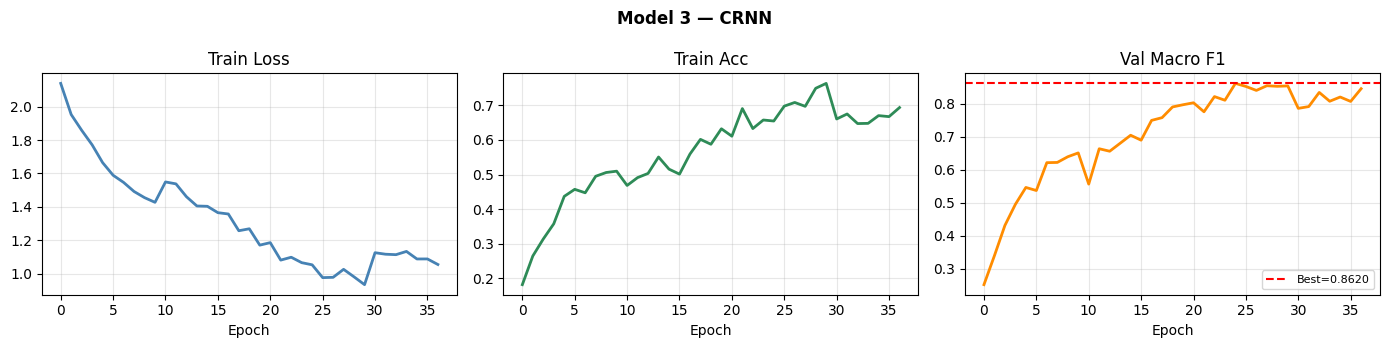

  Model 3  Best Val F1 : 0.8620


In [18]:
print("  Training Model 3 — CRNN …")
tr_dl3 = DataLoader(CachedDataset1Ch(tr_items, augment=True),
                    batch_size=16, shuffle=True,
                    num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
va_dl3 = DataLoader(CachedDataset1Ch(va_items, augment=False),
                    batch_size=16, shuffle=False,
                    num_workers=cfg.NUM_WORKERS, pin_memory=True)

m3, f1_m3, hist3 = train_model(
    CRNN().to(cfg.DEVICE),
    tr_dl3, va_dl3, "model3_crnn",
    lr=2e-4, epochs=cfg.EPOCHS, patience=12
)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, data, title, col in zip(
    axes,
    [hist3["train_loss"], hist3["train_acc"], hist3["val_f1"]],
    ["Train Loss", "Train Acc", "Val Macro F1"],
    ["steelblue", "seagreen", "darkorange"]
):
    ax.plot(data, color=col, lw=2); ax.set_title(title)
    ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
axes[2].axhline(f1_m3, ls="--", color="red", lw=1.5, label=f"Best={f1_m3:.4f}")
axes[2].legend(fontsize=8)
plt.suptitle("Model 3 — CRNN", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/model3_history.png", dpi=130)
plt.show()
print(f"  Model 3  Best Val F1 : {f1_m3:.4f}")



# BEST MODEL

In [19]:
best_name = ["Scratch CNN", "EfficientNet-B2", "CRNN"][
    [f1_m1, f1_m2, f1_m3].index(max(f1_m1, f1_m2, f1_m3))
]
print(f"\n{'═'*46}")
print(f"  ALL MODELS COMPLETE")
print(f"{'─'*46}")
print(f"  Model 1  Scratch CNN      : {f1_m1:.4f}")
print(f"  Model 2  EfficientNet-B2  : {f1_m2:.4f}")
print(f"  Model 3  CRNN             : {f1_m3:.4f}")
print(f"{'─'*46}")
print(f"  Best ▶  {best_name} ({max(f1_m1,f1_m2,f1_m3):.4f})")
print(f"{'═'*46}")


══════════════════════════════════════════════
  ALL MODELS COMPLETE
──────────────────────────────────────────────
  Model 1  Scratch CNN      : 0.8200
  Model 2  EfficientNet-B2  : 0.9195
  Model 3  CRNN             : 0.8620
──────────────────────────────────────────────
  Best ▶  EfficientNet-B2 (0.9195)
══════════════════════════════════════════════


# 11. ENSEMBLE WEIGHT OPTIMIZATION

  Computing validation probabilities … done
  Searching weights  1000/1000  best so far: 0.8865

  ┌────────────────────────────────────────────┐
  │  ENSEMBLE WEIGHT OPTIMIZATION              │
  ├────────────────────────────────────────────┤
  │  Model 1  (Scratch CNN)        0.7900  │
  │  Model 2  (EfficientNet-B2)    0.8776  │
  │  Model 3  (CRNN)               0.7826  │
  ├────────────────────────────────────────────┤
  │  Equal-weight ensemble         0.8646  │
  │  Optimal ensemble              0.8865  │
  │    Improvement                +0.0219  │
  ├────────────────────────────────────────────┤
  │  Weights → M1: 0.0050  M2: 0.5445  M3: 0.4505  │
  └────────────────────────────────────────────┘



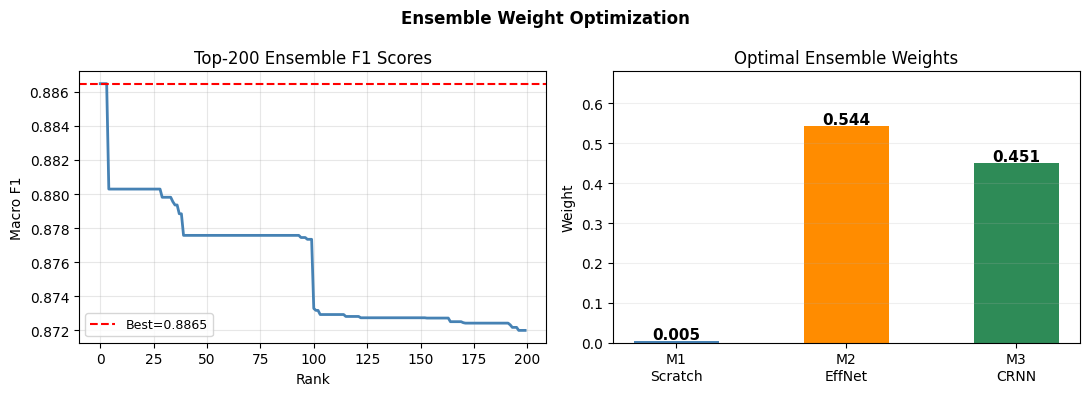

In [20]:
@torch.no_grad()
def get_val_probs(model, items, three_ch=False):
    DS = TrainDataset3Ch if three_ch else TrainDataset1Ch
    ds = DS(items, augment=False, mashup_prob=0.0, noise_prob=0.0)
    dl = DataLoader(ds, batch_size=24, num_workers=cfg.NUM_WORKERS)
    model.eval()
    probs, labs = [], []
    for x, y in dl:
        probs.extend(F.softmax(model(x.to(cfg.DEVICE)), -1).cpu().numpy())
        labs.extend(y.numpy())
    return np.array(probs), np.array(labs)


print("  Computing validation probabilities …", end=" ", flush=True)
vp1, vlabs = get_val_probs(m1, va_items, three_ch=False)
vp2, _     = get_val_probs(m2, va_items, three_ch=True)
vp3, _     = get_val_probs(m3, va_items, three_ch=False)
print("done")

# ── Individual & equal-weight F1 ──────────────────────────
_f1_m1    = f1_score(vlabs, vp1.argmax(1), average="macro")
_f1_m2    = f1_score(vlabs, vp2.argmax(1), average="macro")
_f1_m3    = f1_score(vlabs, vp3.argmax(1), average="macro")
_f1_equal = f1_score(vlabs, ((vp1+vp2+vp3)/3).argmax(1), average="macro")

# ── Dirichlet weight search ───────────────────────────────
TRIALS = 1000
best_f1_ens, best_w = 0.0, [1/3, 1/3, 1/3]
weight_history = []

for trial in range(TRIALS):
    w   = np.random.dirichlet(np.ones(3))
    ens = w[0]*vp1 + w[1]*vp2 + w[2]*vp3
    f1  = f1_score(vlabs, ens.argmax(1), average="macro")
    weight_history.append(f1)
    if f1 > best_f1_ens:
        best_f1_ens = f1; best_w = w.tolist()
    print(f"  Searching weights  {trial+1:>4}/{TRIALS}  "
          f"best so far: {best_f1_ens:.4f}", end="\r")

print()   # newline after the overwrite

# ── Summary table ─────────────────────────────────────────
col = 44
print(f"\n  ┌{'─'*col}┐")
print(f"  │  {'ENSEMBLE WEIGHT OPTIMIZATION':<{col-2}}│")
print(f"  ├{'─'*col}┤")
print(f"  │  {'Model 1  (Scratch CNN)':<28}  {_f1_m1:.4f}  │")
print(f"  │  {'Model 2  (EfficientNet-B2)':<28}  {_f1_m2:.4f}  │")
print(f"  │  {'Model 3  (CRNN)':<28}  {_f1_m3:.4f}  │")
print(f"  ├{'─'*col}┤")
print(f"  │  {'Equal-weight ensemble':<28}  {_f1_equal:.4f}  │")
print(f"  │  {'Optimal ensemble':<28}  {best_f1_ens:.4f}  │")
print(f"  │  {'  Improvement':<28} +{best_f1_ens-_f1_equal:.4f}  │")
print(f"  ├{'─'*col}┤")
print(f"  │  Weights → M1: {best_w[0]:.4f}  M2: {best_w[1]:.4f}  M3: {best_w[2]:.4f}  │")
print(f"  └{'─'*col}┘\n")

# ── Plot ──────────────────────────────────────────────────
w_scores = sorted(weight_history, reverse=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(w_scores[:200], color="steelblue", lw=2)
ax1.axhline(best_f1_ens, ls="--", color="red", lw=1.5, label=f"Best={best_f1_ens:.4f}")
ax1.set_title("Top-200 Ensemble F1 Scores")
ax1.set_xlabel("Rank"); ax1.set_ylabel("Macro F1")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

labels = ["M1\nScratch", "M2\nEffNet", "M3\nCRNN"]
colors = ["steelblue", "darkorange", "seagreen"]
bars   = ax2.bar(labels, best_w, color=colors, width=0.5)
for bar, v in zip(bars, best_w):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
ax2.set_title("Optimal Ensemble Weights")
ax2.set_ylabel("Weight"); ax2.set_ylim(0, max(best_w) * 1.25)
ax2.grid(True, alpha=0.2, axis="y")

plt.suptitle("Ensemble Weight Optimization", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/ensemble_weights.png", dpi=130)
plt.show()

# 12. VALIDATION RESULTS & VISUALIZATIONS


  ┌────────────────────────────────────────────┐
  │  VALIDATION RESULTS — ENSEMBLE             │
  ├────────────────────────────────────────────┤
  │  blues                 F1: 0.9286              │
  │  classical             F1: 0.9375              │
  │  country               F1: 0.8235              │
  │  disco                 F1: 0.8148              │
  │  hiphop                F1: 0.8387              │
  │  jazz                  F1: 0.9655              │
  │  metal                 F1: 0.9677              │
  │  pop                   F1: 0.9333              │
  │  reggae                F1: 0.7586              │
  │  rock                  F1: 0.8966              │
  ├────────────────────────────────────────────┤
  │  Macro F1              F1: 0.8865              │
  └────────────────────────────────────────────┘



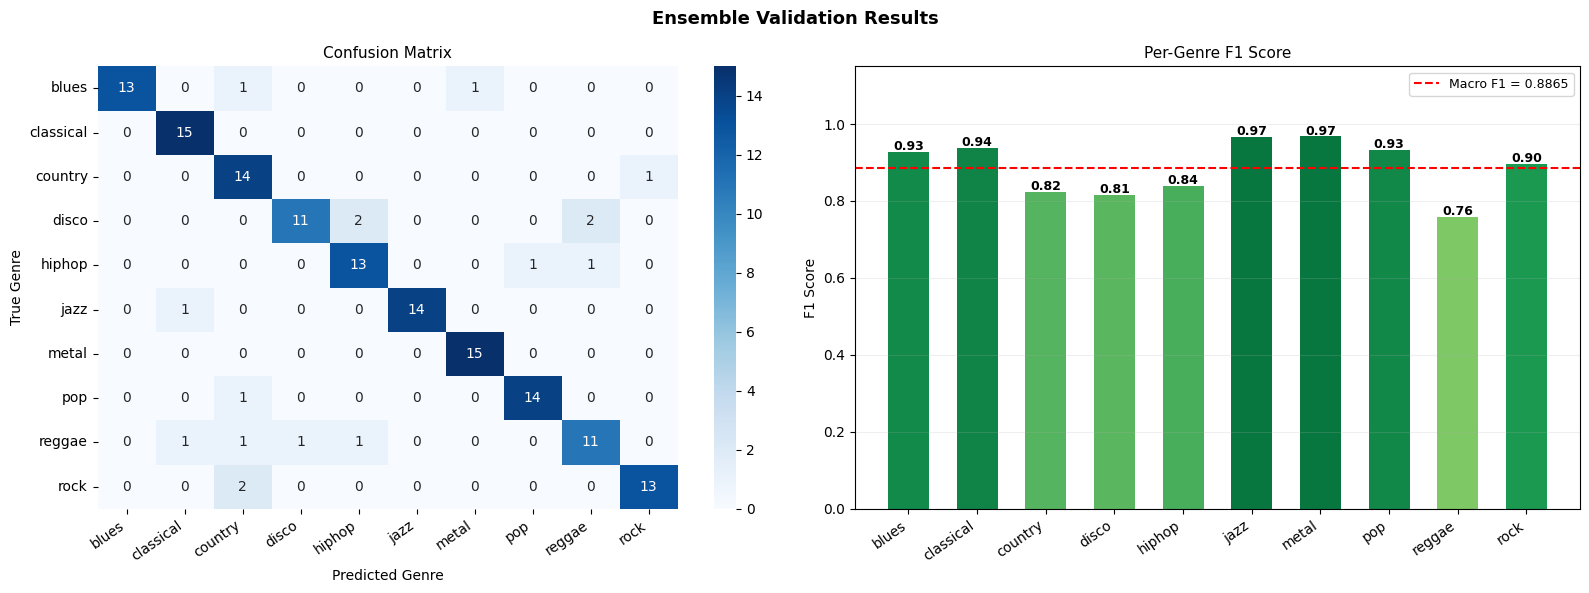

  Plot saved → validation_results.png


In [21]:
val_ens   = best_w[0]*vp1 + best_w[1]*vp2 + best_w[2]*vp3
val_preds = val_ens.argmax(1)
final_f1  = f1_score(vlabs, val_preds, average="macro")

rep = classification_report(vlabs, val_preds,
                             target_names=cfg.GENRES, output_dict=True)
f1s = [rep[g]["f1-score"] for g in cfg.GENRES]

col = 44
print(f"\n  ┌{'─'*col}┐")
print(f"  │  {'VALIDATION RESULTS — ENSEMBLE':<{col-2}}│")
print(f"  ├{'─'*col}┤")
for g, f in zip(cfg.GENRES, f1s):
    print(f"  │  {g:<20}  F1: {f:.4f}{'':>{col-30}}│")
print(f"  ├{'─'*col}┤")
print(f"  │  {'Macro F1':<20}  F1: {final_f1:.4f}{'':>{col-30}}│")
print(f"  └{'─'*col}┘\n")

# ── Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Ensemble Validation Results", fontsize=13, fontweight="bold")

cm = confusion_matrix(vlabs, val_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cfg.GENRES, yticklabels=cfg.GENRES, ax=axes[0])
axes[0].set_title("Confusion Matrix", fontsize=11)
axes[0].set_ylabel("True Genre"); axes[0].set_xlabel("Predicted Genre")
plt.setp(axes[0].get_xticklabels(), rotation=35, ha="right")

cols = plt.cm.RdYlGn(np.array(f1s))
bars = axes[1].bar(cfg.GENRES, f1s, color=cols, width=0.6)
for bar, v in zip(bars, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
axes[1].axhline(final_f1, color="red", ls="--", lw=1.5,
                label=f"Macro F1 = {final_f1:.4f}")
axes[1].set_title("Per-Genre F1 Score", fontsize=11)
axes[1].set_ylabel("F1 Score"); axes[1].set_ylim(0, 1.15)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2, axis="y")
plt.setp(axes[1].get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/validation_results.png", dpi=130)
plt.show()
print(f"  Plot saved → validation_results.png")






# 13. TEST INFERENCE & SUBMISSION 

  TEST INFERENCE & SUBMISSION GENERATION

  test.csv loaded   : 3020 rows
  Columns           : ['id', 'filename']

  Running TTA inference (5 passes each)...
  TTA 5/5 done
    Model 1 done — probs shape: (3020, 10)
  TTA 5/5 done
    Model 2 done — probs shape: (3020, 10)
  TTA 5/5 done
    Model 3 done — probs shape: (3020, 10)

  ✅ submission.csv saved — 3020 rows

  Prediction distribution:
    classical     3020  100.0%  ██████████████████████████████████████████████████


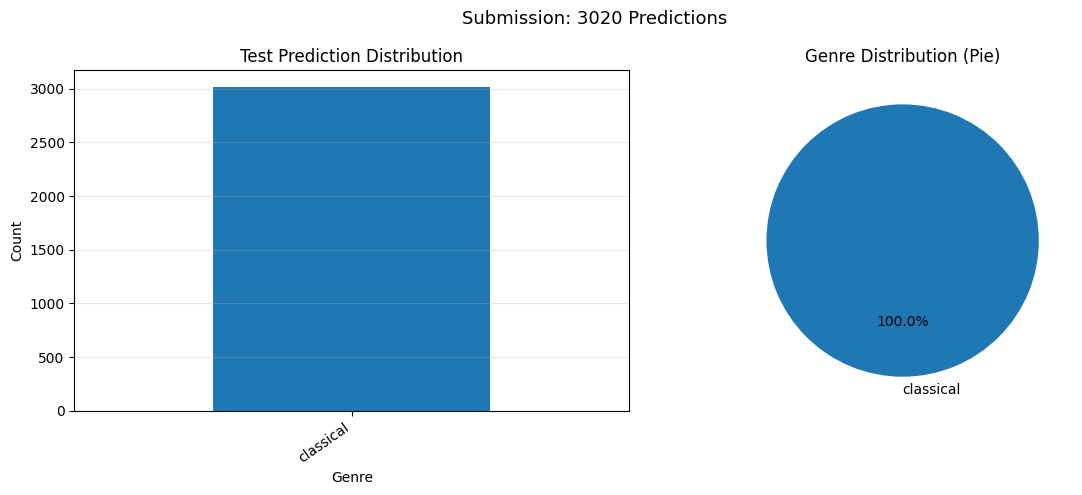


  First 10 rows of submission:
  id     genre
0001 classical
0002 classical
0003 classical
0004 classical
0005 classical
0006 classical
0007 classical
0008 classical
0009 classical
0010 classical

  All output files saved in: /kaggle/working/
    ✓ model1_scratch.pth
    ✓ model2_effnet.pth
    ✓ model3_crnn.pth
    ✓ feature_extraction.png
    ✓ model1_history.png
    ✓ model2_history.png
    ✓ model3_history.png
    ✓ ensemble_weights.png
    ✓ validation_results.png
    ✓ submission_distribution.png
    ✓ submission.csv


In [22]:
print("=" * 55)
print("  TEST INFERENCE & SUBMISSION GENERATION")
print("=" * 55)

test_df = pd.read_csv(cfg.TEST_CSV)
print(f"\n  test.csv loaded   : {len(test_df)} rows")
print(f"  Columns           : {list(test_df.columns)}")

# Build test DataLoaders
td_1ch = DataLoader(TestDataset(test_df, cfg.MASHUP_DIR, three_channel=False),
                     batch_size=16, shuffle=False, num_workers=cfg.NUM_WORKERS)
td_3ch = DataLoader(TestDataset(test_df, cfg.MASHUP_DIR, three_channel=True),
                     batch_size=12, shuffle=False, num_workers=cfg.NUM_WORKERS)

print(f"\n  Running TTA inference (5 passes each)...")
ids,  tp1 = predict_tta(m1, td_1ch, cfg.DEVICE, tta=5)
print(f"    Model 1 done — probs shape: {tp1.shape}")
_,    tp2 = predict_tta(m2, td_3ch, cfg.DEVICE, tta=5)
print(f"    Model 2 done — probs shape: {tp2.shape}")
_,    tp3 = predict_tta(m3, td_1ch, cfg.DEVICE, tta=5)
print(f"    Model 3 done — probs shape: {tp3.shape}")

# Final ensemble
final_p   = best_w[0]*tp1 + best_w[1]*tp2 + best_w[2]*tp3
pred_idx  = final_p.argmax(1)
genres    = [cfg.IDX2GENRE[i] for i in pred_idx]

# Build submission
sub = pd.DataFrame({"id": ids, "genre": genres})
sub["id"] = sub["id"].apply(lambda x: str(x).zfill(4))
sub = sub.sort_values("id").reset_index(drop=True)
sub.to_csv(f"{cfg.OUTPUT_DIR}/submission.csv", index=False)

print(f"\n  ✅ submission.csv saved — {len(sub)} rows")
print(f"\n  Prediction distribution:")
counts = sub["genre"].value_counts()
for genre, cnt in counts.items():
    pct = cnt / len(sub) * 100
    bar = "█" * int(pct / 2)
    print(f"    {genre:<12} {cnt:>5}  {pct:5.1f}%  {bar}")

# Plot prediction distribution
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
colors = plt.cm.tab10(np.linspace(0,1,10))
counts.plot(kind="bar", color=colors, ax=plt.gca())
plt.title("Test Prediction Distribution"); plt.ylabel("Count")
plt.xlabel("Genre"); plt.xticks(rotation=35, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.subplot(1,2,2)
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=colors, startangle=90)
plt.title("Genre Distribution (Pie)")
plt.suptitle(f"Submission: {len(sub)} Predictions", fontsize=13)
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/submission_distribution.png", dpi=130)
plt.show()

print(f"\n  First 10 rows of submission:")
print(sub.head(10).to_string(index=False))
print(f"\n  All output files saved in: {cfg.OUTPUT_DIR}/")
print(f"    ✓ model1_scratch.pth")
print(f"    ✓ model2_effnet.pth")
print(f"    ✓ model3_crnn.pth")
print(f"    ✓ feature_extraction.png")
print(f"    ✓ model1_history.png")
print(f"    ✓ model2_history.png")
print(f"    ✓ model3_history.png")
print(f"    ✓ ensemble_weights.png")
print(f"    ✓ validation_results.png")
print(f"    ✓ submission_distribution.png")
print(f"    ✓ submission.csv")
